# PCA, SVD e Kernel PCA para Machine Learning

## Objetivo

Comparar o desempenho de modelos de Machine Learning utilizando:

- Dados originais (64 dimensões)
- PCA
- Truncated SVD
- Kernel PCA

O dataset utilizado será o Digits do Scikit-Learn.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA, TruncatedSVD, KernelPCA

from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report


## Carregando o Dataset

O dataset Digits possui imagens 8x8 de dígitos manuscritos, totalizando 64 atributos por observação.


In [3]:
digits = load_digits()

X = digits.data
y = digits.target

print("Formato:", X.shape)


Formato: (1797, 64)


## Divisão Treino/Teste

Utilizaremos holdout para comparar os métodos de redução de dimensionalidade.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


## Baseline: Dados Originais

Primeiro treinamos um KNN sem redução de dimensionalidade.


In [5]:
baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

baseline.fit(X_train, y_train)

pred_baseline = baseline.predict(X_test)

acc_baseline = accuracy_score(y_test, pred_baseline)

print("Accuracy:", acc_baseline)


Accuracy: 0.9703703703703703


## PCA

O PCA busca componentes que maximizam a variância explicada.


In [11]:
pca_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=30)),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

pca_pipeline.fit(X_train, y_train)

pred_pca = pca_pipeline.predict(X_test)

acc_pca = accuracy_score(y_test, pred_pca)

print("Accuracy:", acc_pca)


Accuracy: 0.9703703703703703


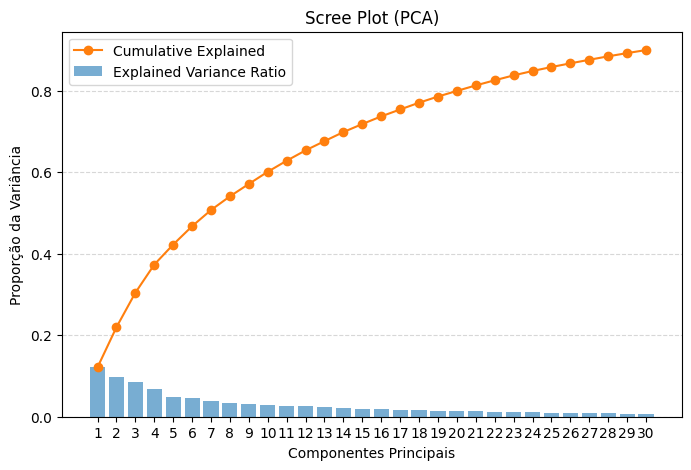

In [16]:
pca = pca_pipeline.named_steps["pca"]
evr = pca.explained_variance_ratio_
cum_evr = np.cumsum(evr)
components = np.arange(1, len(evr) + 1)

plt.figure(figsize=(8, 5))
plt.bar(components, evr, alpha=0.6, label="Explained Variance Ratio")
plt.plot(components, cum_evr, marker="o", color="C1", label="Cumulative Explained")
plt.xticks(components)
plt.xlabel("Componentes Principais")
plt.ylabel("Proporção da Variância")
plt.title("Scree Plot (PCA)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

## Truncated SVD

O SVD decompõe a matriz em componentes ortogonais e é amplamente utilizado para compressão de dados.


In [8]:
svd_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svd", TruncatedSVD(n_components=10, random_state=42)),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

svd_pipeline.fit(X_train, y_train)

pred_svd = svd_pipeline.predict(X_test)

acc_svd = accuracy_score(y_test, pred_svd)

print("Accuracy:", acc_svd)


Accuracy: 0.9444444444444444


## Kernel PCA

O Kernel PCA utiliza transformações não lineares para capturar estruturas mais complexas.


In [9]:
kpca_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("kpca", KernelPCA(
        n_components=10,
        kernel="rbf"
    )),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

kpca_pipeline.fit(X_train, y_train)

pred_kpca = kpca_pipeline.predict(X_test)

acc_kpca = accuracy_score(y_test, pred_kpca)

print("Accuracy:", acc_kpca)


Accuracy: 0.937037037037037


## Comparação dos Resultados

Agora comparamos diretamente os desempenhos.


In [10]:
results = pd.DataFrame({
    "Método":[
        "Original",
        "PCA",
        "SVD",
        "Kernel PCA"
    ],
    "Accuracy":[
        acc_baseline,
        acc_pca,
        acc_svd,
        acc_kpca
    ]
})

results.sort_values(
    "Accuracy",
    ascending=False
)


,Método,Accuracy
0,Original,0.970370
1,PCA,0.944444
2,SVD,0.944444
3,Kernel PCA,0.937037


## Discussão

Observe:

- Qual técnica preservou melhor a informação?
- Houve perda de desempenho após a redução?
- Qual método apresentou melhor equilíbrio entre compressão e performance?
- O Kernel PCA trouxe benefícios sobre os métodos lineares?


## Conclusões

- Redução de dimensionalidade pode reduzir custo computacional.
- Nem sempre reduz a performance preditiva.
- PCA e SVD costumam apresentar resultados semelhantes.
- Kernel PCA pode capturar relações não lineares.
- A escolha depende do problema e do compromisso entre compressão e desempenho.
